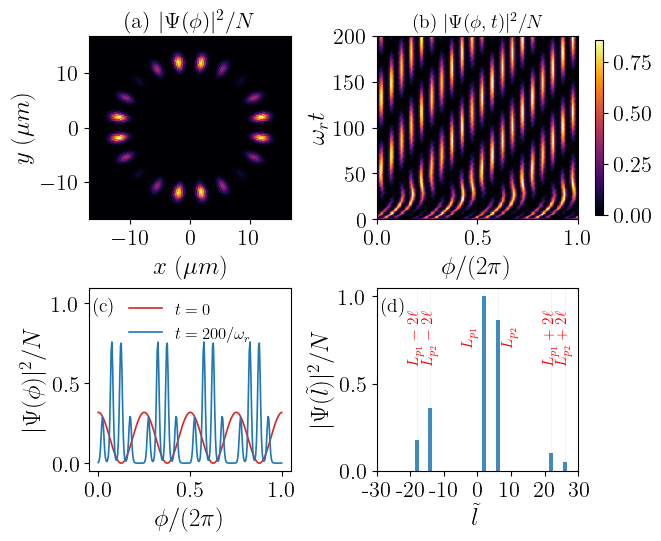

In [3]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD DATA
# ============================================================
data = np.load(r"Figure_10_data.npz")

# ---- unpack ----
X = data["X"]
Y = data["Y"]
density_2D = data["density_2D"]

phi_e10 = data["phi_e10"]
t_e10 = data["t_e10"]
density_10 = data["density_10"]

phi = data["phi"]
psi_init = data["psi_init"]
psi_final = data["psi_final"]

l_vals = data["l_vals"]
psi_k_density = data["psi_k_density"]

L_p1 = int(data["L_p1"])
L_p2 = int(data["L_p2"])
ell = int(data["l"])   # IMPORTANT: stored as "l"

# ============================================================
# APS / PRA STYLE
# ============================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
})

# ============================================================
# PANEL LABEL FUNCTION
# ============================================================
def add_panel_label(ax, label):
    ax.text(0.02, 0.95, label,
            transform=ax.transAxes,
            fontsize=14,
            va='top', ha='left')

# ============================================================
# FIGURE LAYOUT (2x2)
# ============================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(6.5, 5.3),
    constrained_layout=True
)

ax_a, ax_b = axes[0]
ax_c, ax_d = axes[1]

# ============================================================
# (a) RING DENSITY
# ============================================================
im_a = ax_a.pcolormesh(
    X * 1e6,
    Y * 1e6,
    density_2D,
    cmap='inferno',
    shading='auto'
)

ax_a.set_xlabel(r'$x\;(\mu m)$')
ax_a.set_ylabel(r'$y\;(\mu m)$')
ax_a.set_title(r'(a) $|\Psi(\phi)|^2/N$', fontsize=16)

# ============================================================
# (b) TIME EVOLUTION
# ============================================================
im_b = ax_b.pcolormesh(
    phi_e10/(2*np.pi),
    t_e10,
    density_10,
    cmap='inferno',
    shading='auto'
)

ax_b.set_xlabel(r'$\phi/(2\pi)$')
ax_b.set_ylabel(r'$\omega_r t$')
ax_b.set_xlim([0, 1])
ax_b.set_ylim([0, 200])
ax_b.set_title(r'(b) $|\Psi(\phi,t)|^2/N$', fontsize=14)

# ============================================================
# (c) REAL-SPACE DENSITY
# ============================================================
ax_c.plot(
    phi/(2*np.pi),
    np.abs(psi_init)**2,
    color='tab:red',
    lw=1.2,
    label=r'$t = 0$'
)

ax_c.plot(
    phi/(2*np.pi),
    np.abs(psi_final)**2,
    color='tab:blue',
    lw=1.2,
    label=r'$t = 200/\omega_r$'
)

ax_c.set_xlabel(r'$\phi/(2\pi)$')
ax_c.set_ylabel(r'$|\Psi(\phi)|^2/N$')
ax_c.set_ylim([-0.05, 1.1])
ax_c.legend(frameon=False)

add_panel_label(ax_c, '(c)')

# ============================================================
# (d) FOURIER SPECTRUM
# ============================================================
ax_d.bar(
    l_vals,
    psi_k_density,
    width=1.2,
    alpha=0.85
)

# ---- build peak positions ----
tick_positions = []
for n in [-1, 0, 1]:
    tick_positions.append(L_p1 + 2*n*ell)
    tick_positions.append(L_p2 + 2*n*ell)

# ---- axis limits ----
xmin, xmax = -30, 30
ax_d.set_xlim([xmin, xmax])

# ---- uniform ticks ----
xticks = np.arange(xmin, xmax + 1, 10)
ax_d.set_xticks(xticks)
ax_d.set_xticklabels([f"{int(x)}" for x in xticks])

# ---- manual annotations ----
manual_labels = [
    (L_p1 - 4, 0.7, r'$L_{p_1}$'),
    (L_p1 + 2*ell, 0.6, r'$L_{p_1}+2\ell$'),
    (L_p1 - 2*ell, 0.6, r'$L_{p_1}-2\ell$'),

    (L_p2 + 4, 0.7, r'$L_{p_2}$'),
    (L_p2 + 2*ell, 0.6, r'$L_{p_2}+2\ell$'),
    (L_p2 - 2*ell, 0.6, r'$L_{p_2}-2\ell$'),
]

for x, y, lab in manual_labels:
    ax_d.text(
        x, y, lab,
        color='red',
        rotation=90,
        ha='center',
        va='bottom',
        fontsize=11
    )

# ---- guide lines ----
for x in tick_positions:
    ax_d.axvline(x, ls=':', lw=0.5, alpha=0.25)

ax_d.set_xlabel(r'$\tilde{l}$')
ax_d.set_ylabel(r'$|\Psi(\tilde{l})|^2/N$')

add_panel_label(ax_d, '(d)')

# ============================================================
# SHARED COLORBAR (a & b)
# ============================================================
cbar = fig.colorbar(
    im_b,
    ax=[ax_a, ax_b],
    shrink=0.95,
    pad=0.005
)

# SHOW
# ============================================================
plt.show()